Using device: cuda


C:\Users\arman\AppData\Local\Temp\ipykernel_30060\3744332510.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='quality_grade', order=['Low', 'Medium', 'High', 'Premium'], ax=axes[0], palette='viridis')
C:\Users\arman\AppData\Local\Temp\ipykernel_30060\3744332510.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='quality_grade', y='thread_count', order=['Low', 'Medium', 'High', 'Premium'], ax=axes[1], palette='viridis')


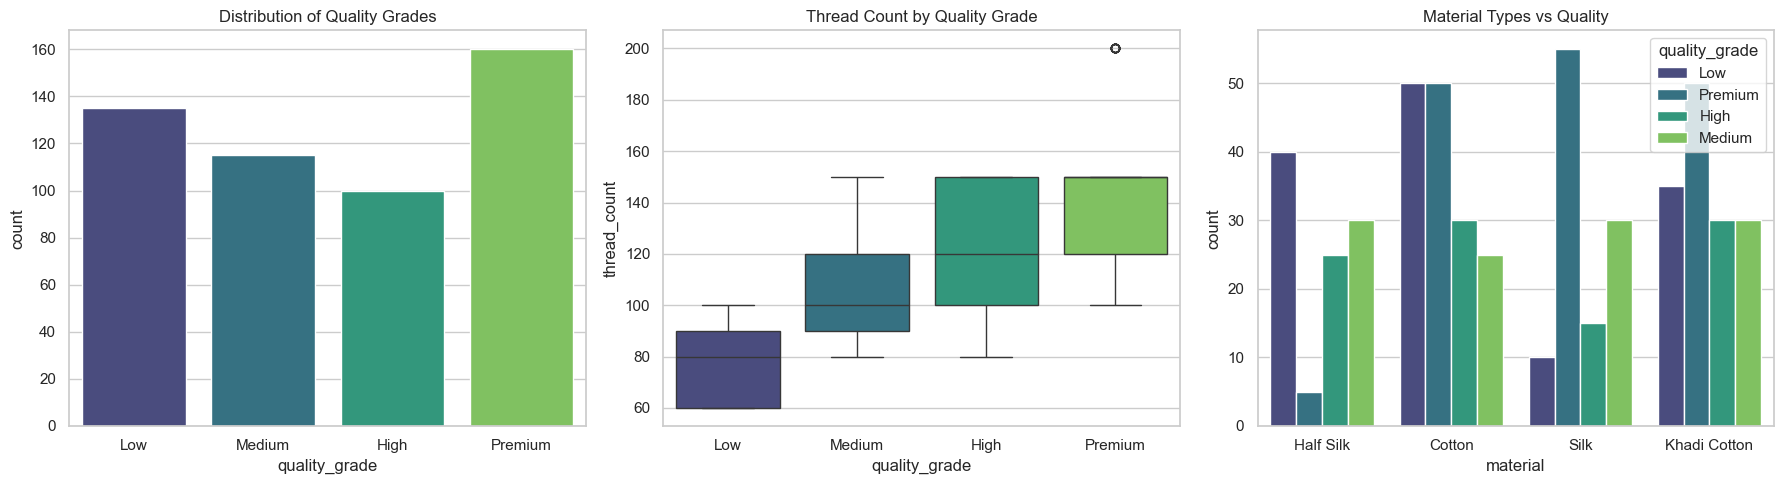


--- Visualizing Multimodal Data Mapping ---


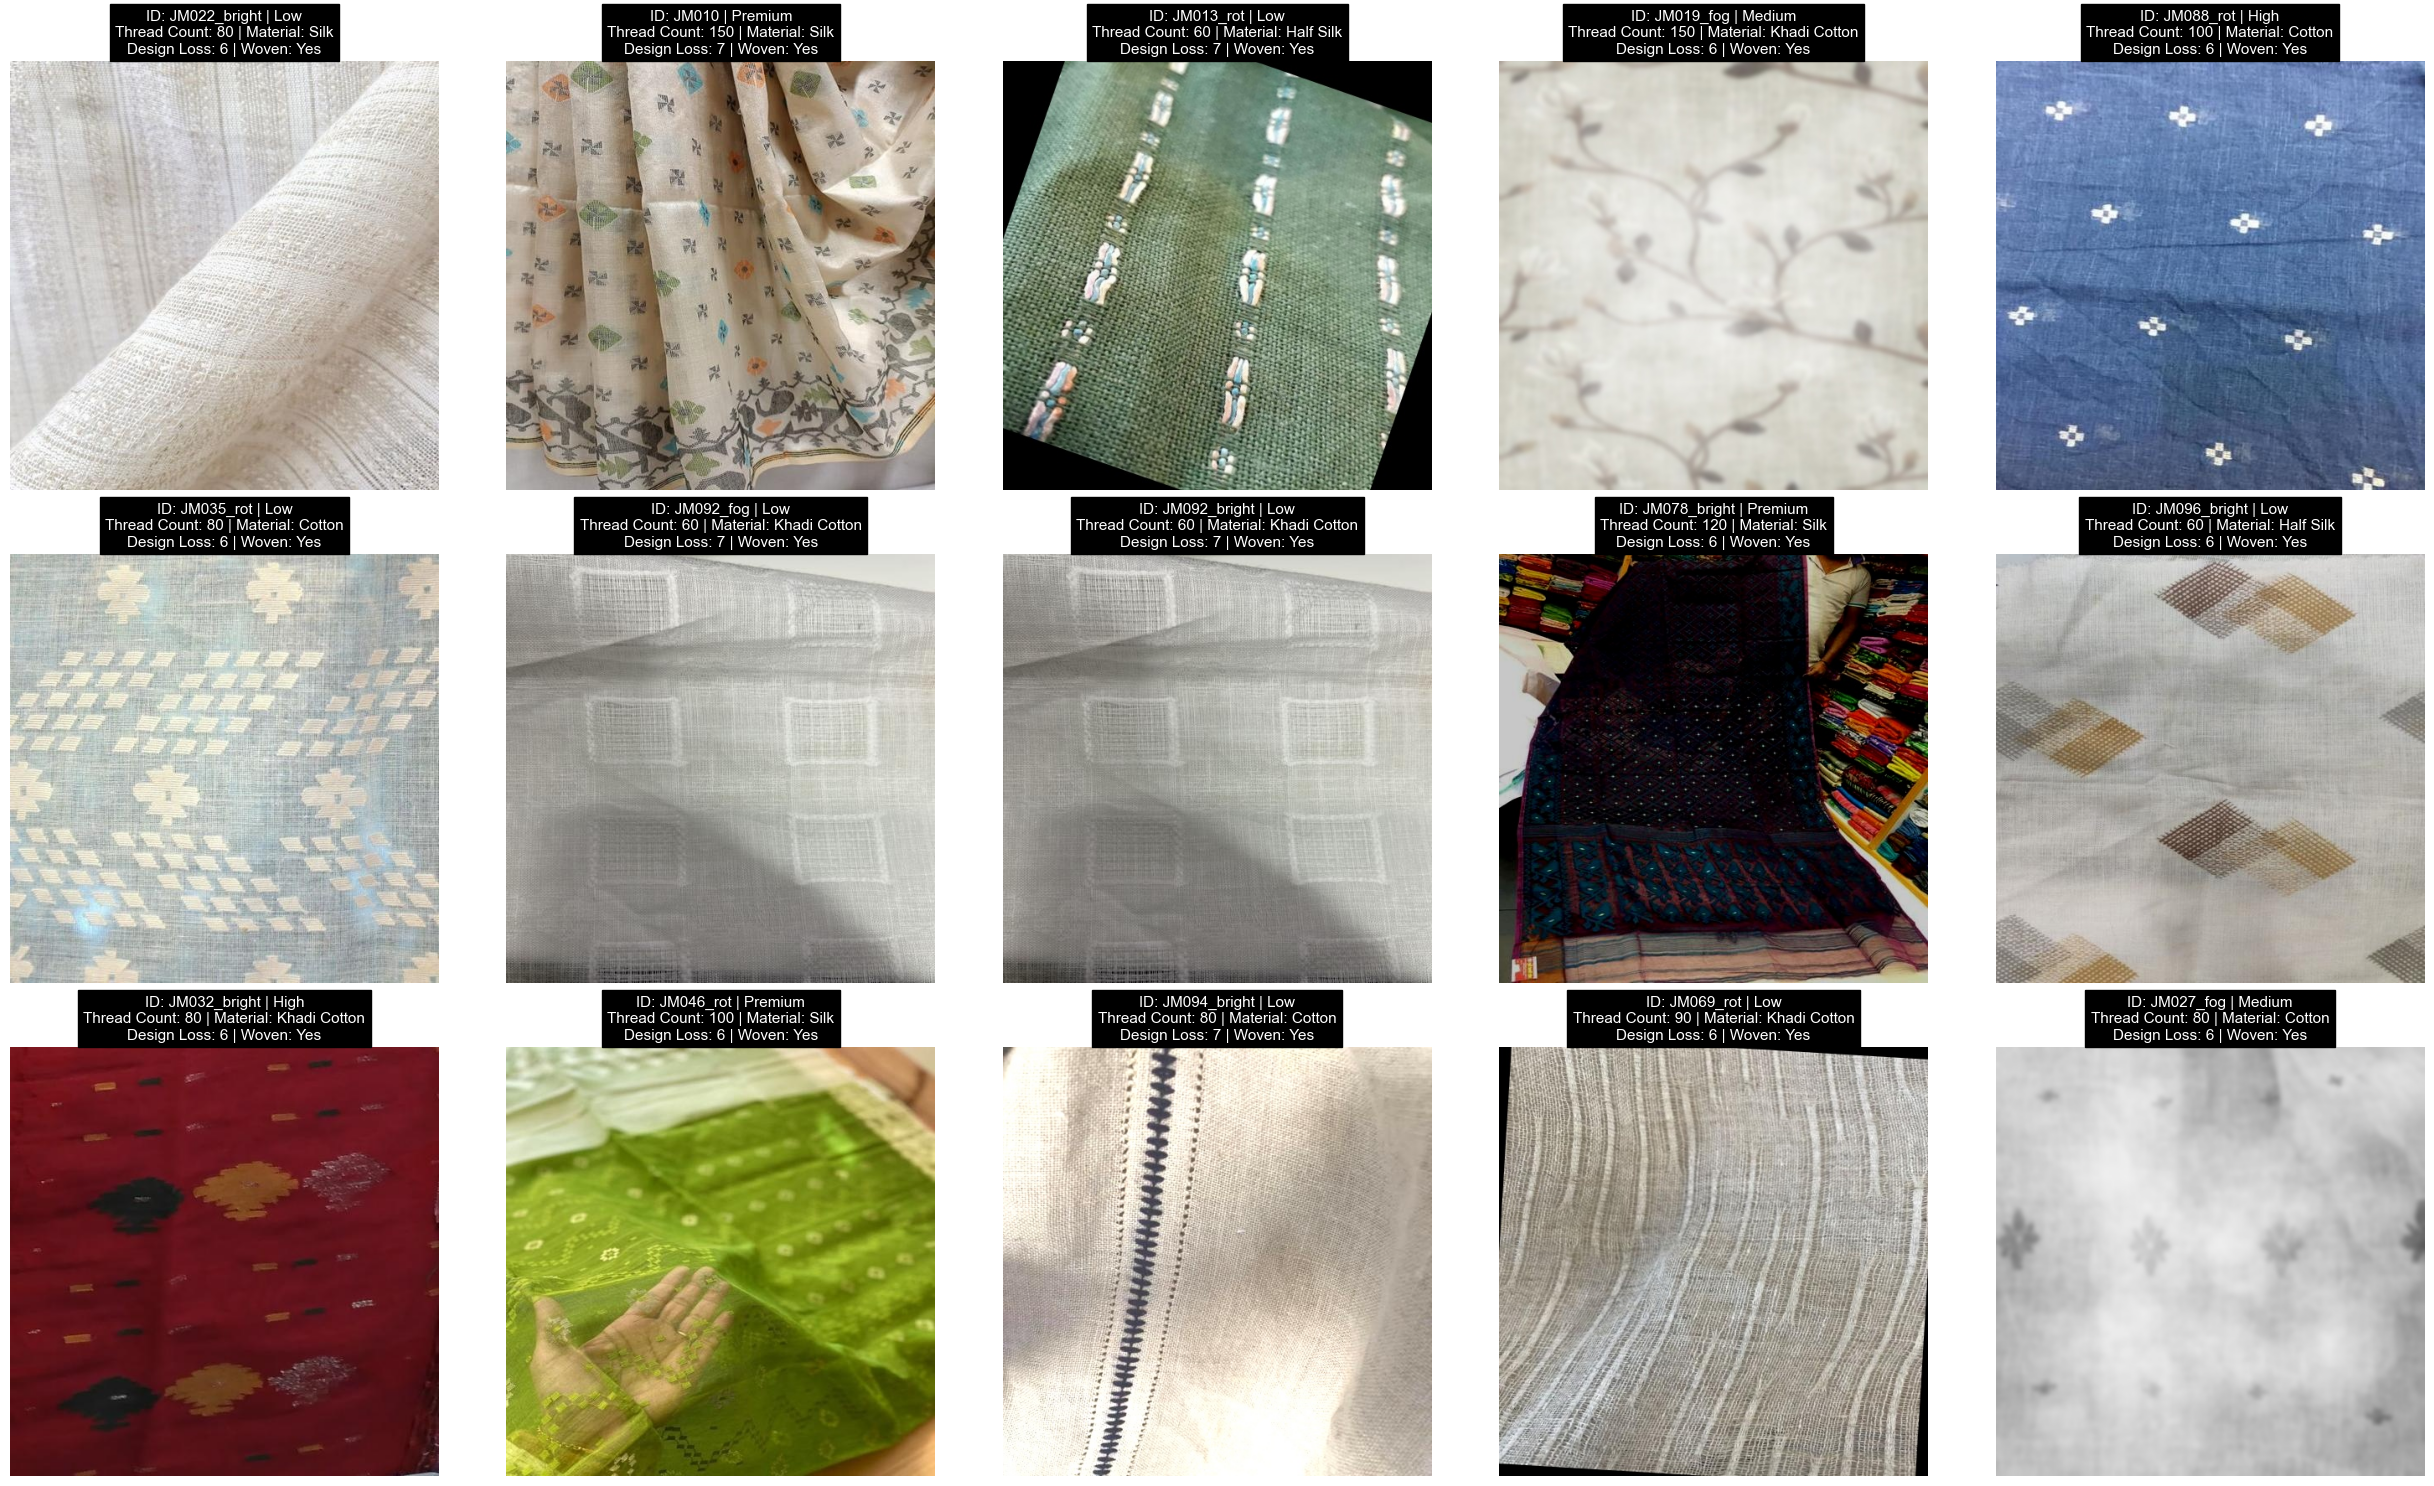

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Load the Tabular Data
excel_filename = 'Jamdani_Samples_Augmented.xlsx' # Ensure this matches your uploaded file name
df = pd.read_excel(excel_filename)

# 2. Exploratory Data Visualization (Charts)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))



sns.countplot(data=df, x='quality_grade', order=['Low', 'Medium', 'High', 'Premium'], ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Quality Grades')

sns.boxplot(data=df, x='quality_grade', y='thread_count', order=['Low', 'Medium', 'High', 'Premium'], ax=axes[1], palette='viridis')
axes[1].set_title('Thread Count by Quality Grade')

sns.countplot(data=df, x='material', hue='quality_grade', ax=axes[2], palette='viridis')
axes[2].set_title('Material Types vs Quality')

plt.tight_layout()
plt.show()


import math

# 3. Visualize Sample Images with their Mapped Features
print("\n--- Visualizing Multimodal Data Mapping ---")
image_folder = './Images' # Ensure your images are inside this folder

# Sample 15 random rows to visualize in a matrix
num_samples = 15
sample_df = df.sample(n=num_samples)

# Define the matrix layout (e.g., 5 columns)
cols = 5
rows = math.ceil(num_samples / cols)

# Adjust figsize so the matrix is wide and tall enough to read the text
# Width=25, Height=15 provides a good balance for a 5-column grid
plt.figure(figsize=(25, 15))

for i, (index, row) in enumerate(sample_df.iterrows()):
    img_name = row['image_name']
    img_path = os.path.join(image_folder, img_name)

    # Subplot takes (rows, columns, current_index)
    plt.subplot(rows, cols, i + 1)

    # Check if the image actually exists in the folder before trying to draw it
    if os.path.exists(img_path):
        img = Image.open(img_path).convert('RGB')
        plt.imshow(img)

        # Map the tabular features to the image title
        feature_text = (
            f"ID: {row['image_id']} | {row['quality_grade']}\n"
            f"Thread Count: {row['thread_count']} | Material: {row['material']}\n"
            f"Design Loss: {row['design_loss']} | Woven: {row['handwoven']}"
        )

        # Font size increased slightly to remain readable in the larger grid
        plt.title(feature_text, fontsize=11, loc='center', backgroundcolor='black', color='white')
        plt.axis('off')
    else:
        # Fallback if the image is missing from the folder
        plt.text(0.5, 0.5, f"Image Not Found:\n{img_name}",
                 ha='center', va='center', fontsize=12, color='red')
        plt.axis('off')

# tight_layout ensures the titles and images don't overlap in the matrix
plt.tight_layout()
plt.show()

In [21]:
missing = [f for f in df['image_name'] if not os.path.exists(os.path.join(image_folder, f))]
print(f"{len(missing)} / {len(df)} files missing")
print(missing[:20])

0 / 510 files missing
[]


--- Advanced Statistical Visualizations for Report ---


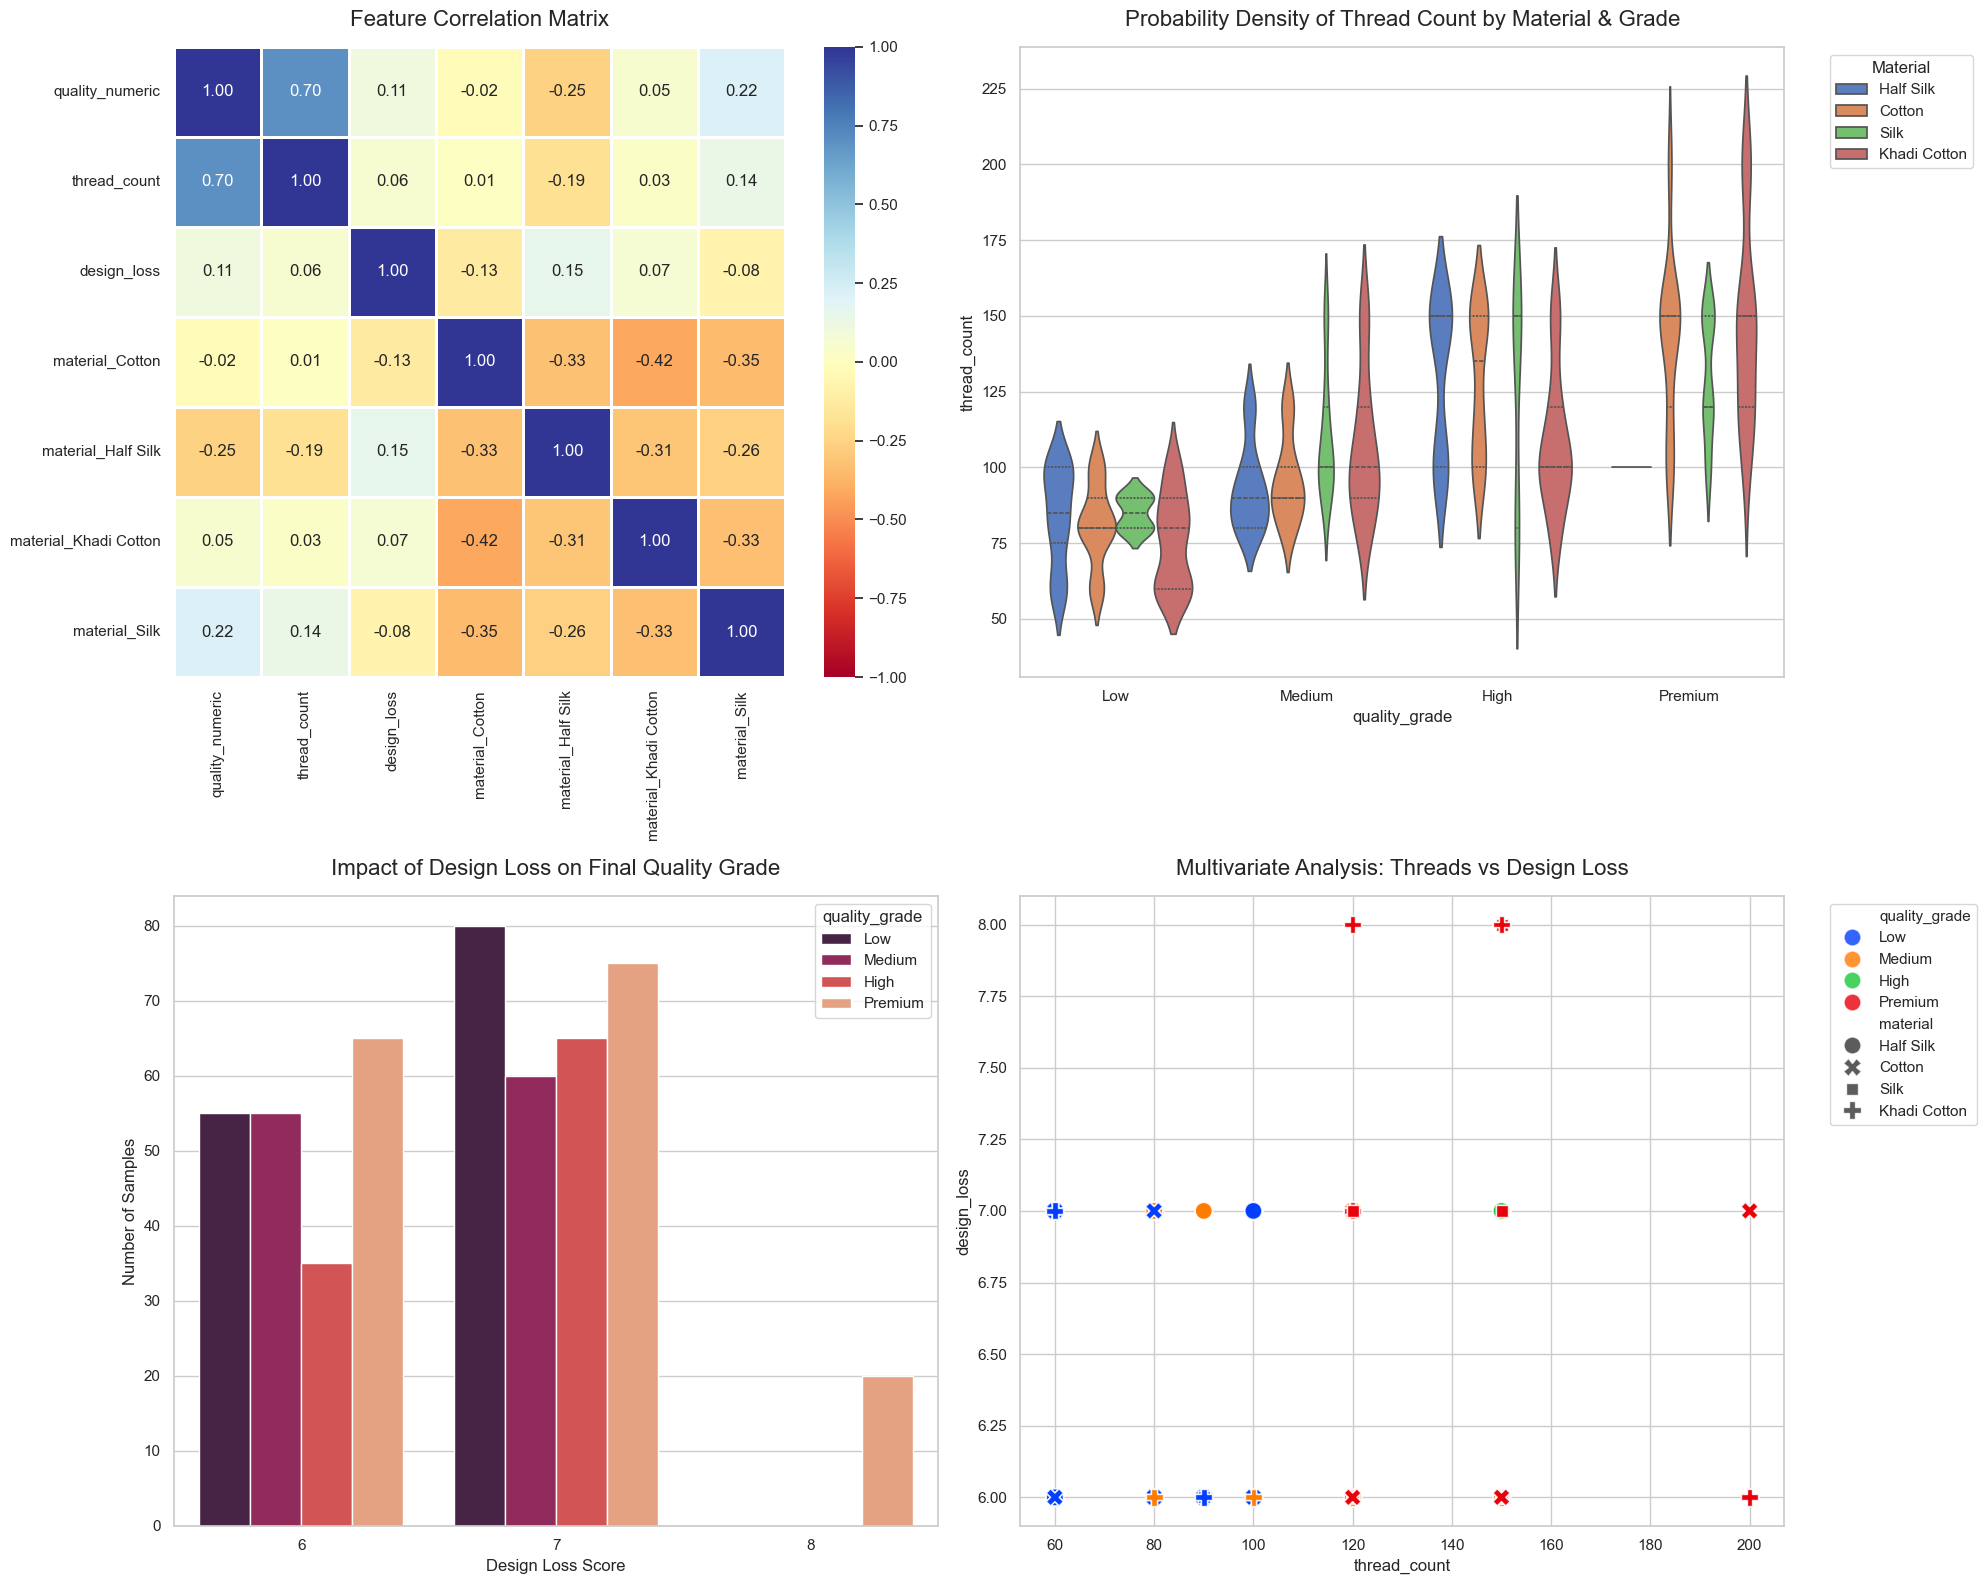

In [22]:

print("--- Advanced Statistical Visualizations for Report ---")

# Create a 2x2 grid for advanced plots
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# Plot 1: Feature Correlation Heatmap
# ---------------------------------------------------------
# We map ordinal quality to numbers so we can calculate mathematical correlation
grade_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Premium': 3}
df_corr = df.copy()
df_corr['quality_numeric'] = df_corr['quality_grade'].map(grade_map)

# One-hot encode the materials to see how specific fabrics correlate
df_corr = pd.get_dummies(df_corr, columns=['material'])
corr_columns = ['quality_numeric', 'thread_count', 'design_loss'] + [c for c in df_corr.columns if 'material_' in c]

# Compute and plot the correlation matrix
corr_matrix = df_corr[corr_columns].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu', fmt=".2f", linewidths=1, ax=axes[0, 0], vmin=-1, vmax=1)
axes[0, 0].set_title('Feature Correlation Matrix', fontsize=16, pad=15)

# ---------------------------------------------------------
# Plot 2: Violin Plot (Distribution Density)
# ---------------------------------------------------------
# Violin plots are great for academic papers. They show both the boxplot and the exact probability density.
sns.violinplot(data=df, x='quality_grade', y='thread_count', hue='material',
               order=['Low', 'Medium', 'High', 'Premium'],
               inner="quartile", palette='muted', ax=axes[0, 1])
axes[0, 1].set_title('Probability Density of Thread Count by Material & Grade', fontsize=16, pad=15)
axes[0, 1].legend(title='Material', bbox_to_anchor=(1.05, 1), loc='upper left')

# ---------------------------------------------------------
# Plot 3: Impact of Design Loss on Quality
# ---------------------------------------------------------
# Shows if higher design loss forces a saree into a lower grade category
sns.countplot(data=df, x='design_loss', hue='quality_grade',
              hue_order=['Low', 'Medium', 'High', 'Premium'],
              palette='rocket', ax=axes[1, 0])
axes[1, 0].set_title('Impact of Design Loss on Final Quality Grade', fontsize=16, pad=15)
axes[1, 0].set_xlabel('Design Loss Score')
axes[1, 0].set_ylabel('Number of Samples')

# ---------------------------------------------------------
# Plot 4: Multivariate Scatter Plot
# ---------------------------------------------------------
# Combines 4 dimensions of data: X (Thread Count), Y (Design Loss), Color (Grade), Shape (Material)
sns.scatterplot(data=df, x='thread_count', y='design_loss', hue='quality_grade',
                style='material', s=150, alpha=0.8,
                hue_order=['Low', 'Medium', 'High', 'Premium'],
                palette='bright', ax=axes[1, 1])
axes[1, 1].set_title('Multivariate Analysis: Threads vs Design Loss', fontsize=16, pad=15)
axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [23]:
# 1. Encode Target Labels (Low, Medium, High, Premium -> 0, 1, 2, 3)
label_encoder = LabelEncoder()
df['target'] = label_encoder.fit_transform(df['quality_grade'])

# 2. Encode Categorical Features & Scale Numerical Features
df = pd.get_dummies(df, columns=['material'], drop_first=False)
feature_cols = ['thread_count', 'design_loss'] + [col for col in df.columns if col.startswith('material_')]

scaler = StandardScaler()
df[['thread_count', 'design_loss']] = scaler.fit_transform(df[['thread_count', 'design_loss']])

# 3. Train-Test Split (80% Train, 20% Test)
# IMPORTANT: since the data is augmented (_bright/_flip/_fog/_rot copies of the
# same original photo), we must split by the ORIGINAL sample, not by row.
# Otherwise near-duplicate images of the same fabric can end up in both train
# and test, which leaks information and inflates test accuracy artificially.
df['base_id'] = df['image_id'].str.replace(r'_(bright|flip|fog|rot)$', '', regex=True)

unique_samples = df.drop_duplicates(subset='base_id')[['base_id', 'target']]
train_ids, test_ids = train_test_split(
    unique_samples['base_id'],
    test_size=0.2,
    random_state=42,
    stratify=unique_samples['target']
)

train_df = df[df['base_id'].isin(train_ids)].reset_index(drop=True)
test_df = df[df['base_id'].isin(test_ids)].reset_index(drop=True)

# 4. Define PyTorch Image Transformations
# MobileNetV2 expects images resized to 224x224 and normalized with specific mean/std
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 5. Build Custom PyTorch Dataset
class JamdaniMultimodalDataset(Dataset):
    def __init__(self, dataframe, img_folder, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_folder = img_folder
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Image
        img_name = self.dataframe.loc[idx, 'image_name']
        img_path = os.path.join(self.img_folder, img_name)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        # Tabular data
        tabular_data = self.dataframe.loc[idx, feature_cols].values.astype(np.float32)
        tabular_tensor = torch.tensor(tabular_data)

        # Label
        label = self.dataframe.loc[idx, 'target']
        label_tensor = torch.tensor(label, dtype=torch.long)

        return image, tabular_tensor, label_tensor

# 6. Create DataLoaders (Batches the data automatically)
train_dataset = JamdaniMultimodalDataset(train_df, 'Images', transform=image_transforms)
test_dataset = JamdaniMultimodalDataset(test_df, 'Images', transform=image_transforms)

train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)

print(f"Tabular features dimension: {len(feature_cols)}")
feature_cols

Tabular features dimension: 6


['thread_count',
 'design_loss',
 'material_Cotton',
 'material_Half Silk',
 'material_Khadi Cotton',
 'material_Silk']

In [ ]:
class MultimodalLateFusion(nn.Module):
    def __init__(self, tabular_dim, num_classes=4):
        super(MultimodalLateFusion, self).__init__()

        # --- Branch 1: Image Feature Extractor ---
        # Load pre-trained MobileNetV2
        mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        self.image_features = mobilenet.features

        # Freeze the pre-trained weights
        for param in self.image_features.parameters():
            param.requires_grad = False

        # Reduce MobileNet's 1280 feature maps down to 128
        self.image_pool_and_fc = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(1280, 128),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # --- Branch 2: Tabular Feature Extractor ---
        self.tabular_model = nn.Sequential(
            nn.Linear(tabular_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # --- Branch 3: Fusion & Classification Head ---
        # Concatenated size: 128 (image) + 64 (tabular) = 192
        self.fusion_model = nn.Sequential(
            nn.Linear(128 + 64, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes) # Raw logits (No softmax needed here for PyTorch CrossEntropyLoss)
        )
        
        
    def forward(self, image_x, tabular_x):
        # Pass image through CNN
        img_out = self.image_features(image_x)
        img_out = self.image_pool_and_fc(img_out)

        # Pass tabular data through Dense layers
        tab_out = self.tabular_model(tabular_x)

        # Concatenate on the feature dimension (dim=1)
        combined = torch.cat((img_out, tab_out), dim=1)

        # Pass through final fusion layers
        output = self.fusion_model(combined)
        return output

# Instantiate the model and move it to the GPU
tabular_input_dim = len(feature_cols)
model = MultimodalLateFusion(tabular_dim=tabular_input_dim).to(device)
print(tabular_input_dim)

print(model)


6
MultimodalLateFusion(
  (image_features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): Bat

Starting training...


Epoch 1/30 | Train Loss: 1.2664 Acc: 0.3778 | Val Loss: 1.0644 Acc: 0.5048
Epoch 2/30 | Train Loss: 0.8912 Acc: 0.6099 | Val Loss: 0.8337 Acc: 0.5429
Epoch 3/30 | Train Loss: 0.5979 Acc: 0.7827 | Val Loss: 0.7674 Acc: 0.5714
Epoch 4/30 | Train Loss: 0.3702 Acc: 0.8790 | Val Loss: 0.9434 Acc: 0.6762
Epoch 5/30 | Train Loss: 0.2683 Acc: 0.9111 | Val Loss: 1.1098 Acc: 0.5429
Epoch 6/30 | Train Loss: 0.2752 Acc: 0.8938 | Val Loss: 1.2149 Acc: 0.5905
Epoch 7/30 | Train Loss: 0.2105 Acc: 0.9358 | Val Loss: 1.0684 Acc: 0.6095
Epoch 8/30 | Train Loss: 0.1618 Acc: 0.9432 | Val Loss: 1.1891 Acc: 0.6190
Epoch 9/30 | Train Loss: 0.1144 Acc: 0.9580 | Val Loss: 1.1869 Acc: 0.6000
Epoch 10/30 | Train Loss: 0.0830 Acc: 0.9802 | Val Loss: 1.1504 Acc: 0.5905
Epoch 11/30 | Train Loss: 0.1465 Acc: 0.9432 | Val Loss: 1.2263 Acc: 0.6095
Epoch 12/30 | Train Loss: 0.1093 Acc: 0.9728 | Val Loss: 1.2805 Acc: 0.5905
Epoch 13/30 | Train Loss: 0.1098 Acc: 0.9580 | Val Loss: 1.3410 Acc: 0.5524
Epoch 14/30 | Train L

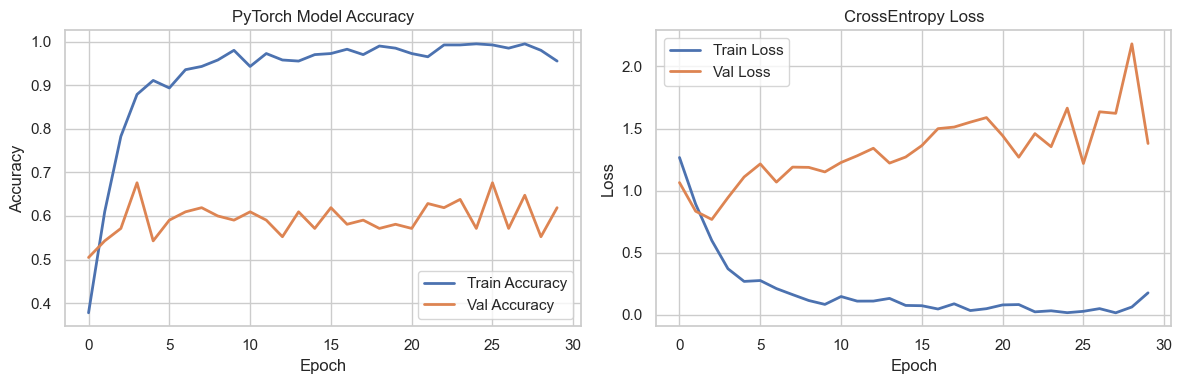

In [25]:
# Hyperparameters
epochs = 30
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Tracking history for plotting
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Starting training...")

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train() # Set model to training mode
    running_loss, running_corrects, total_samples = 0.0, 0, 0

    for images, tabular, labels in train_loader:
        # Move data to GPU
        images, tabular, labels = images.to(device), tabular.to(device), labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images, tabular)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels.data).item()
        total_samples += images.size(0)

    epoch_train_loss = running_loss / total_samples
    epoch_train_acc = running_corrects / total_samples

    # --- VALIDATION PHASE ---
    model.eval() # Set model to evaluation mode (disables dropout)
    val_loss, val_corrects, val_samples = 0.0, 0, 0

    with torch.no_grad(): # Disable gradient calculation for speed
        for images, tabular, labels in test_loader:
            images, tabular, labels = images.to(device), tabular.to(device), labels.to(device)

            outputs = model(images, tabular)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * images.size(0)
            val_corrects += torch.sum(preds == labels.data).item()
            val_samples += images.size(0)

    epoch_val_loss = val_loss / val_samples
    epoch_val_acc = val_corrects / val_samples

    # Save metrics
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")

# Plotting the Results
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy', lw=2)
plt.plot(history['val_acc'], label='Val Accuracy', lw=2)
plt.title('PyTorch Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', lw=2)
plt.plot(history['val_loss'], label='Val Loss', lw=2)
plt.title('CrossEntropy Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [26]:
# Install Optuna silently
!pip install -q optuna
import optuna


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\arman\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
train_dataset = JamdaniMultimodalDataset(train_df, 'Images', transform=image_transforms)
val_dataset = JamdaniMultimodalDataset(test_df, 'Images', transform=image_transforms)

train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)


In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import optuna


NUM_CLASSES = 4
TABULAR_DIM = len(feature_cols)# <-- Replace with your actual number of tabular columns
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. Define the Multi-Modal Architecture ---
class MultiModalNet(nn.Module):
    def __init__(self, base_image_model, tabular_dim, num_classes, dropout_rate=0.2):
        super(MultiModalNet, self).__init__()

        # Base image extractor (MobileNetV2 features)
        self.image_backbone = base_image_model.features

        # --- Branch 1: Image Pool & FC ---
        # MobileNetV2 outputs 1280 channels
        self.image_pool_and_fc = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(1280, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate) # Using Optuna's dropout
        )

        # --- Branch 2: Tabular Feature Extractor ---
        self.tabular_model = nn.Sequential(
            nn.Linear(tabular_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate) # Using Optuna's dropout
        )

        # --- Branch 3: Fusion & Classification Head ---
        self.fusion_model = nn.Sequential(
            nn.Linear(128 + 64, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate), # Using Optuna's dropout
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, image, tabular):
        img_features = self.image_backbone(image)
        img_out = self.image_pool_and_fc(img_features)
        tab_out = self.tabular_model(tabular)
        fused = torch.cat((img_out, tab_out), dim=1)
        return self.fusion_model(fused)


# --- 2. Initialize Model Function ---
def get_multimodal_model(dropout_rate=0.2):
    """Initializes MobileNetV2 and wraps it in the MultiModalNet."""
    base_model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

    # Freeze image feature extractor layers for faster hyperparameter search
    for param in base_model.features.parameters():
        param.requires_grad = False

    # Instantiate our custom class
    model = MultiModalNet(
        base_image_model=base_model,
        tabular_dim=TABULAR_DIM,
        num_classes=NUM_CLASSES,
        dropout_rate=dropout_rate
    )
    return model


# --- 3. Optuna Objective Function ---
def objective(trial):
    # Suggest Hyperparameters
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["AdamW", "Adam", "SGD"])

    model = get_multimodal_model(dropout_rate=dropout).to(device)
    modelcheck=model;
    criterion = nn.CrossEntropyLoss()


    # Get only the un-frozen parameters (the newly added linear and fusion layers)
    trainable_params = [p for p in model.parameters() if p.requires_grad]

    if optimizer_name == "SGD":
        optimizer = optim.SGD(trainable_params, lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        optimizer = getattr(optim, optimizer_name)(trainable_params, lr=lr, weight_decay=weight_decay)

    epochs_per_trial = 5
    for epoch in range(epochs_per_trial):
        model.train()

        # --- Training Loop ---
        for batch in train_loader:
            # Safely unpack Image, Tabular, and Labels
            if isinstance(batch, dict):
                images = batch['image']
                tabular = batch['tabular'] # <-- Ensure this matches your dataset keys
                labels = batch['label']
            else:
                # Assumes dataset returns: (image, tabular, label)
                images, tabular, labels = batch[0], batch[1], batch[2]

            images = images.to(device)
            tabular = tabular.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            # Forward pass requires both inputs
            outputs = model(images, tabular)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # --- Validation Loop ---
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for batch in val_loader:
                if isinstance(batch, dict):
                    images = batch['image']
                    tabular = batch['tabular']
                    labels = batch['label']
                else:
                    images, tabular, labels = batch[0], batch[1], batch[2]

                images = images.to(device)
                tabular = tabular.to(device)
                labels = labels.to(device)

                # Forward pass requires both inputs
                outputs = model(images, tabular)

                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_acc = correct / total

        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return val_acc

In [29]:
# Create study and run optimization
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=15)

print("\n--- Optuna Study Summary ---")
print(f"Best Validation Accuracy: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-09-23 08:09:53,970] A new study created in memory with name: no-name-5efa4c16-0bd7-4023-8b5f-d3db0a6692da
[I 2026-09-23 08:10:22,665] Trial 0 finished with value: 0.22857142857142856 and parameters: {'lr': 1.398385902922859e-05, 'dropout': 0.2349532412914177, 'weight_decay': 0.0007184016030502947, 'optimizer': 'AdamW'}. Best is trial 0 with value: 0.22857142857142856.
[I 2026-09-23 08:10:49,273] Trial 1 finished with value: 0.23809523809523808 and parameters: {'lr': 8.19493958305526e-05, 'dropout': 0.3501880170237738, 'weight_decay': 2.8871746357269813e-05, 'optimizer': 'SGD'}. Best is trial 1 with value: 0.23809523809523808.
[I 2026-09-23 08:11:15,284] Trial 2 finished with value: 0.5333333333333333 and parameters: {'lr': 0.0005324322737774402, 'dropout': 0.45263730425722193, 'weight_decay': 1.2019523479004336e-06, 'optimizer': 'AdamW'}. Best is trial 2 with value: 0.5333333333333333.
[I 2026-09-23 08:11:41,316] Trial 3 finished with value: 0.6 and parameters: {'lr': 0.0001332


--- Optuna Study Summary ---
Best Validation Accuracy: 0.6571
Best Hyperparameters:
  lr: 0.008228640385181788
  dropout: 0.194104279586456
  weight_decay: 0.00011793825517545582
  optimizer: AdamW


In [30]:
import copy
print("\n--- Training Final Model ---")
best_params = study.best_params

#print(best_params["batch_size"])

# Use a default batch size if not tuned by Optuna
batch_size = best_params.get("batch_size", 32)

# If train_dataset exists, rebuild loaders; otherwise use existing loaders
if "train_dataset" in globals() and "val_dataset" in globals():
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

final_model = get_multimodal_model(dropout_rate=best_params["dropout"]).to(device)

# Unfreeze top layers of MobileNet for fine-tuning
# The corrected line
for param in final_model.image_backbone[-3:].parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()

if best_params["optimizer"] == "SGD":
    optimizer = optim.SGD(
        final_model.parameters(),
        lr=best_params["lr"],
        momentum=0.9,
        weight_decay=best_params["weight_decay"]
    )
else:
    optimizer = getattr(optim, best_params["optimizer"])(
        final_model.parameters(),
        lr=best_params["lr"],
        weight_decay=best_params["weight_decay"]
    )

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

num_epochs = 30
best_accuracy = 0.0
best_model_weights = copy.deepcopy(final_model.state_dict())

for epoch in range(num_epochs):
    final_model.train()
    running_loss, correct, total = 0.0, 0, 0

    # Robust unpacking for multimodal or tuple batches
    for batch in train_loader:
        if isinstance(batch, dict):
            images, tabular, labels = batch['image'], batch['tabular'], batch['label']
        else:
            images, tabular, labels = batch[0], batch[1], batch[2]

        images, tabular, labels = images.to(device), tabular.to(device), labels.to(device)

        optimizer.zero_grad()
        # The corrected line:
        outputs = final_model(images, tabular)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    scheduler.step()
    train_loss = running_loss / total
    train_acc = correct / total

    # Validation
    final_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for batch in val_loader:
            if isinstance(batch, dict):
                images, tabular, labels = batch['image'], batch['tabular'], batch['label']
            else:
                images, tabular, labels = batch[0], batch[1], batch[2]

            images, tabular, labels = images.to(device), tabular.to(device), labels.to(device)
            # The corrected line:
            outputs = final_model(images, tabular)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1:02d}/{num_epochs:02d} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    if val_acc > best_accuracy:
        best_accuracy = val_acc
        best_model_weights = copy.deepcopy(final_model.state_dict())

# Save best model checkpoint
final_model.load_state_dict(best_model_weights)
torch.save(final_model.state_dict(), 'best_mobilenet_jamdani.pth')
print(f"\nFinal Best Validation Accuracy: {best_accuracy:.4f}")
print("Saved model checkpoint as 'best_mobilenet_jamdani.pth' in your Drive!")


--- Training Final Model ---
Epoch 01/30 | Train Loss: 1.1824, Acc: 0.5210 | Val Loss: 13.3980, Acc: 0.3810
Epoch 02/30 | Train Loss: 0.6274, Acc: 0.7506 | Val Loss: 13.5232, Acc: 0.5048
Epoch 03/30 | Train Loss: 0.3234, Acc: 0.8889 | Val Loss: 15.5863, Acc: 0.4476
Epoch 04/30 | Train Loss: 0.4940, Acc: 0.9210 | Val Loss: 6.4831, Acc: 0.3810
Epoch 05/30 | Train Loss: 0.3294, Acc: 0.8790 | Val Loss: 2.8553, Acc: 0.5048
Epoch 06/30 | Train Loss: 0.1695, Acc: 0.9531 | Val Loss: 2.5597, Acc: 0.5905
Epoch 07/30 | Train Loss: 0.1088, Acc: 0.9605 | Val Loss: 1.6887, Acc: 0.5524
Epoch 08/30 | Train Loss: 0.1345, Acc: 0.9753 | Val Loss: 1.8059, Acc: 0.5619
Epoch 09/30 | Train Loss: 0.0616, Acc: 0.9901 | Val Loss: 1.9727, Acc: 0.5238
Epoch 10/30 | Train Loss: 0.0395, Acc: 0.9877 | Val Loss: 2.1679, Acc: 0.5714
Epoch 11/30 | Train Loss: 0.0406, Acc: 0.9926 | Val Loss: 2.1871, Acc: 0.5524
Epoch 12/30 | Train Loss: 0.0087, Acc: 1.0000 | Val Loss: 2.0798, Acc: 0.4857
Epoch 13/30 | Train Loss: 0.075

In [31]:
print("\n--- Optimized Hyperparameters ---")
for key, value in best_params.items():
    print(f"{key}: {value}")


--- Optimized Hyperparameters ---
lr: 0.008228640385181788
dropout: 0.194104279586456
weight_decay: 0.00011793825517545582
optimizer: AdamW


In [32]:
# ==========================================
# MULTIMODAL ONLY STUDY: JAMDANI FABRIC
# Models: DenseNet, ConvNeXt, Swin, MobileNetV3
# ==========================================
import timm
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, mean_squared_error, precision_recall_fscore_support

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

multimodal_results = []
tabular_dim = len(feature_cols)
NUM_CLASSES = 4 # 0=Low, 1=Medium, 2=High, 3=Premium



Using device: cuda



In [33]:
# ---------------------------------------------------------
# 1. HELPER FUNCTION: DETAILED EPOCH TRACKING (MULTIMODAL ONLY)
# ---------------------------------------------------------
def train_eval_multimodal(model, train_loader, test_loader, model_name, epochs=5):
    print(f"==========================================")
    print(f" TRAINING: {model_name}")
    print(f"==========================================")
    
    # Using Adam optimizer with learning rate 0.001
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_samples = 0
        
        progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False, unit="batch")
        
        for batch in progress:
            # Extract Image, Tabular, and Label from your Jamdani DataLoader
            images = batch[0].to(device)
            tabs = batch[1].to(device)
            labels = batch[2].to(device)
            
            optimizer.zero_grad()
            
            # Forward pass: Multimodal fusion
            outputs = model(images, tabs)
            loss = criterion(outputs, labels)
            
            # Backward pass & Optimize
            loss.backward()
            optimizer.step()
            
            # Track Loss and Train Accuracy dynamically
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * labels.size(0)
            running_corrects += torch.sum(preds == labels.data).item()
            total_samples += labels.size(0)
            
            live_acc = (running_corrects / total_samples) * 100
            progress.set_postfix(Loss=f"{loss.item():.4f}", TrainAcc=f"{live_acc:.2f}%")
            
        epoch_loss = running_loss / total_samples
        epoch_train_acc = (running_corrects / total_samples) * 100
        
        # --- Validation Phase ---
        model.eval()
        val_corrects, val_samples = 0, 0
        with torch.no_grad():
            for batch in test_loader:
                images, tabs, labels = batch[0].to(device), batch[1].to(device), batch[2].to(device)
                
                outputs = model(images, tabs)
                _, preds = torch.max(outputs, 1)
                
                val_corrects += torch.sum(preds == labels.data).item()
                val_samples += labels.size(0)
                
        epoch_val_acc = (val_corrects / val_samples) * 100
        print(f"Epoch {epoch+1}/{epochs} Completed | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}%")

    # --- Metric Extraction ---
    print(f"Extracting Final Metrics for {model_name}...\n")
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            images, tabs, labels = batch[0].to(device), batch[1].to(device), batch[2].to(device)
            
            outputs = model(images, tabs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
    rmse = np.sqrt(mean_squared_error(all_labels, all_preds))
    
    return {'Model': model_name, 'Accuracy': epoch_val_acc/100, 'Precision': p, 'Recall': r, 'F1-Score': f1, 'RMSE': rmse}


In [34]:

# ---------------------------------------------------------
# 2. MULTIMODAL FUSION ARCHITECTURE
# ---------------------------------------------------------
class JamdaniMultimodalFusion(nn.Module):
    def __init__(self, tabular_dim, backbone_name, num_classes):
        super(JamdaniMultimodalFusion, self).__init__()
        # Load backbone without classification head (num_classes=0)
        self.vision_backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0)
        
        # Freeze the backbone so we only train the fusion layers
        for param in self.vision_backbone.parameters():
            param.requires_grad = False
            
        # Dynamically determine the output dimension of the chosen backbone
        dummy_input = torch.randn(1, 3, 224, 224)
        vision_dim = self.vision_backbone(dummy_input).shape[1]
        
        # Architecture Branches
        self.vision_fc = nn.Sequential(nn.Linear(vision_dim, 128), nn.ReLU())
        self.tabular_model = nn.Sequential(nn.Linear(tabular_dim, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU())
        
        # Late Fusion Classifier (4 Classes for Jamdani)
        self.fusion_model = nn.Sequential(nn.Linear(128 + 64, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, num_classes))

    def forward(self, img, tab):
        # Extract features from both modalities
        img_feat = self.vision_fc(self.vision_backbone(img))
        tab_feat = self.tabular_model(tab)
        
        # Concatenate and predict
        combined = torch.cat((img_feat, tab_feat), dim=1)
        return self.fusion_model(combined)


In [35]:

# ---------------------------------------------------------
# 3. EXECUTION: TRAIN THE 4 MULTIMODAL MODELS
# ---------------------------------------------------------
# Exact timm registry names for the 4 state-of-the-art backbones
backbones = [
    # --- The Original 4 ---
    'densenet121', 
    'convnext_tiny', 
    'swin_tiny_patch4_window7_224', 
    'mobilenetv3_large_100',
    
    # --- The 4 Academic Standards ---
    'resnet50', 
    'efficientnet_b0', 
    'vit_tiny_patch16_224', 
    
    # --- The 5 New Advanced Models ---
    'seresnet50',             # Squeeze-and-Excitation Network
    'deit_tiny_patch16_224',  # Data-efficient Image Transformer
    'resnet18',               # Lightweight CNN Baseline
    'ghostnet_100',           # Highly efficient "Ghost" feature network
    'regnety_002',            # Neural Architecture Search (AI-designed network)
    'vgg16_bn'
]

for bb in backbones:
    m_model = JamdaniMultimodalFusion(tabular_dim=tabular_dim, backbone_name=bb, num_classes=NUM_CLASSES).to(device)
    res = train_eval_multimodal(m_model, train_loader, test_loader, f"Multimodal Fusion ({bb.upper()})", epochs=3)
    multimodal_results.append(res)


 TRAINING: Multimodal Fusion (DENSENET121)


Epoch 1/3 Completed | Train Loss: 1.2126 | Train Acc: 53.83% | Val Acc: 53.33%


Epoch 2/3 Completed | Train Loss: 0.6449 | Train Acc: 82.72% | Val Acc: 67.62%


Epoch 3/3 Completed | Train Loss: 0.2603 | Train Acc: 93.83% | Val Acc: 62.86%
Extracting Final Metrics for Multimodal Fusion (DENSENET121)...

 TRAINING: Multimodal Fusion (CONVNEXT_TINY)


Epoch 1/3 Completed | Train Loss: 1.0061 | Train Acc: 60.74% | Val Acc: 50.48%


...

Epoch 2/3 Completed | Train Loss: 0.9863 | Train Acc: 64.20% | Val Acc: 51.43%


Epoch 3/3 Completed | Train Loss: 0.6697 | Train Acc: 77.28% | Val Acc: 56.19%
Extracting Final Metrics for Multimodal Fusion (REGNETY_002)...

 TRAINING: Multimodal Fusion (VGG16_BN)


Epoch 1/3 Completed | Train Loss: 1.0370 | Train Acc: 60.00% | Val Acc: 51.43%


Epoch 2/3 Completed | Train Loss: 0.3807 | Train Acc: 89.38% | Val Acc: 45.71%


Epoch 3/3 Completed | Train Loss: 0.1533 | Train Acc: 94.57% | Val Acc: 43.81%
Extracting Final Metrics for Multimodal Fusion (VGG16_BN)...




 JAMDANI FABRIC: MULTIMODAL PERFORMANCE ANALYSIS
                                           Model  Accuracy  Precision  Recall  F1-Score   RMSE
                 Multimodal Fusion (DENSENET121)    0.6286     0.6384  0.6286    0.6114 1.1872
               Multimodal Fusion (CONVNEXT_TINY)    0.4762     0.5077  0.4762    0.4713 1.4475
Multimodal Fusion (SWIN_TINY_PATCH4_WINDOW7_224)    0.5333     0.5298  0.5333    0.5182 1.3663
       Multimodal Fusion (MOBILENETV3_LARGE_100)    0.5429     0.5476  0.5429    0.5436 1.4108
                    Multimodal Fusion (RESNET50)    0.6381     0.6247  0.6381    0.6002 1.0601
             Multimodal Fusion (EFFICIENTNET_B0)    0.4857     0.6108  0.4857    0.5115 1.2536
        Multimodal Fusion (VIT_TINY_PATCH16_224)    0.5143     0.5023  0.5143    0.4939 1.4243
                  Multimodal Fusion (SERESNET50)    0.5714     0.5666  0.5714    0.5543 1.3904
       Multimodal Fusion (DEIT_TINY_PATCH16_224)    0.4952     0.5168  0.4952    0.5021 1.1992


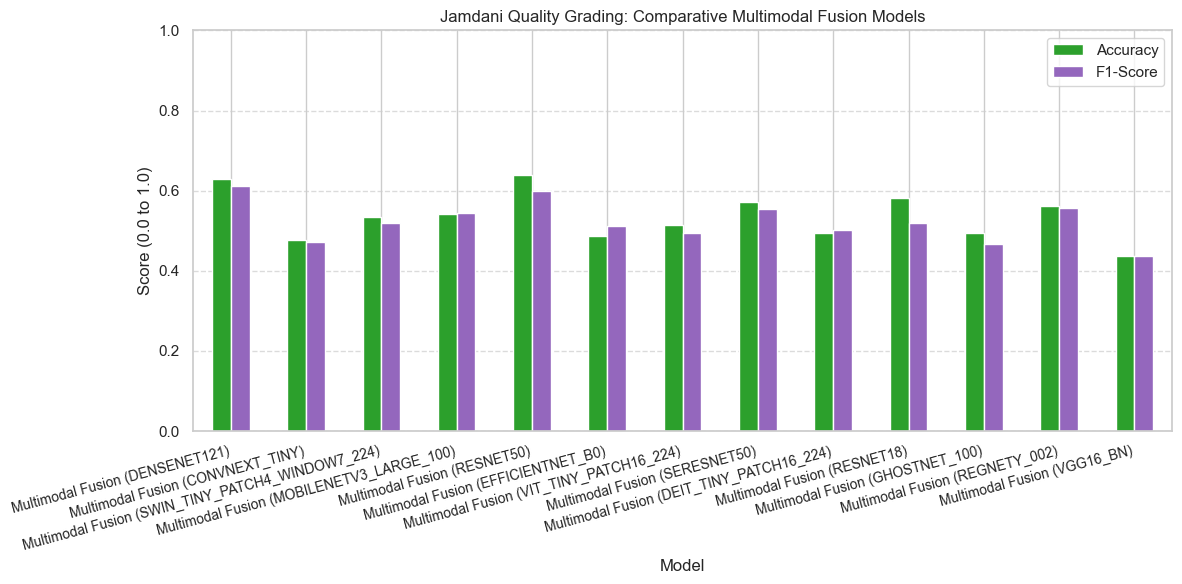

In [36]:

# ---------------------------------------------------------
# 4. FINAL COMPARATIVE VISUALIZATION
# ---------------------------------------------------------
final_df = pd.DataFrame(multimodal_results)

print("\n========================================================")
print(" JAMDANI FABRIC: MULTIMODAL PERFORMANCE ANALYSIS")
print("========================================================")
print(final_df.round(4).to_string(index=False))

# Comparative Bar Chart
final_df.set_index('Model')[['Accuracy', 'F1-Score']].plot(kind='bar', figsize=(12, 6), color=['#2ca02c', '#9467bd'])
plt.title('Jamdani Quality Grading: Comparative Multimodal Fusion Models')
plt.ylabel('Score (0.0 to 1.0)')
plt.ylim(0, 1)
plt.xticks(rotation=15, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

--- Starting 5-Fold Stratified Cross-Validation ---

>> Fold 1/5 Training...
Fold 1 Best Validation Accuracy: 67.62%
*** Fold 1 saved as BEST fold ***

>> Fold 2/5 Training...
Fold 2 Best Validation Accuracy: 79.05%
*** Fold 2 saved as BEST fold ***

>> Fold 3/5 Training...
Fold 3 Best Validation Accuracy: 64.00%

>> Fold 4/5 Training...
Fold 4 Best Validation Accuracy: 77.00%

>> Fold 5/5 Training...
Fold 5 Best Validation Accuracy: 80.00%
*** Fold 5 saved as BEST fold ***

5-Fold CV Final Results:
 - Fold 1: 67.62%
 - Fold 2: 79.05%
 - Fold 3: 64.00%
 - Fold 4: 77.00%
 - Fold 5: 80.00%
Average Accuracy: 73.53% (+/- 6.48%)

Best Fold Information:
Best Fold: 5
Best Fold Accuracy: 80.00%
Best Fold Training Samples: 410
Best Fold Validation Samples: 100


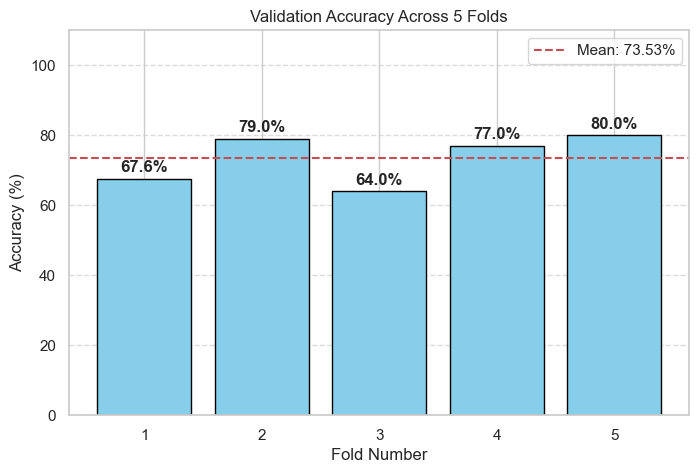

In [37]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
import numpy as np
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

k_folds = 5
epochs_per_fold = 15

skf = StratifiedGroupKFold(n_splits=k_folds, shuffle=True, random_state=42)

fold_results = []
all_train_loss = []
all_val_acc = []

# Store the best fold
best_fold_acc = -1
best_fold_number = None
best_train_loader = None
best_val_loader = None
best_train_df = None
best_val_df = None
best_scaler = None

print(f"--- Starting {k_folds}-Fold Stratified Cross-Validation ---")

for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['target'], groups=df['base_id'])):
    print(f"\n>> Fold {fold + 1}/{k_folds} Training...")

    # Split DataFrame
    train_df = df.iloc[train_idx].copy().reset_index(drop=True)
    val_df = df.iloc[val_idx].copy().reset_index(drop=True)

    # Scale data inside the fold to prevent data leakage
    scaler = StandardScaler()

    train_df[['thread_count', 'design_loss']] = scaler.fit_transform(
        train_df[['thread_count', 'design_loss']]
    )

    val_df[['thread_count', 'design_loss']] = scaler.transform(
        val_df[['thread_count', 'design_loss']]
    )

    # Create datasets
    train_dataset = JamdaniMultimodalDataset(
        train_df, 'Images', transform=image_transforms
    )

    val_dataset = JamdaniMultimodalDataset(
        val_df, 'Images', transform=image_transforms
    )

    # Create DataLoaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=16,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=16,
        shuffle=False
    )

    # Fresh model for each fold
    model = MultimodalLateFusion(
        tabular_dim=len(feature_cols)
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    fold_train_loss_history = []
    fold_val_acc_history = []

    # Training
    for epoch in range(epochs_per_fold):
        model.train()
        running_loss = 0.0

        for images, tabular, labels in train_loader:
            images = images.to(device)
            tabular = tabular.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images, tabular)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        fold_train_loss_history.append(epoch_train_loss)

        # Validation
        model.eval()
        val_corrects = 0
        val_samples = 0

        with torch.no_grad():
            for images, tabular, labels in val_loader:
                images = images.to(device)
                tabular = tabular.to(device)
                labels = labels.to(device)

                outputs = model(images, tabular)
                _, preds = torch.max(outputs, 1)

                val_corrects += torch.sum(preds == labels.data).item()
                val_samples += images.size(0)

        epoch_val_acc = val_corrects / val_samples * 100
        fold_val_acc_history.append(epoch_val_acc)

    # Best accuracy of current fold
    current_fold_best_acc = max(fold_val_acc_history)

    fold_results.append(current_fold_best_acc)
    all_train_loss.append(fold_train_loss_history)
    all_val_acc.append(fold_val_acc_history)

    print(
        f"Fold {fold + 1} Best Validation Accuracy: "
        f"{current_fold_best_acc:.2f}%"
    )

    # Save data from the best-performing fold
    if current_fold_best_acc > best_fold_acc:
        best_fold_acc = current_fold_best_acc
        best_fold_number = fold + 1

        best_train_loader = train_loader
        best_val_loader = val_loader

        best_train_df = train_df.copy()
        best_val_df = val_df.copy()

        best_scaler = copy.deepcopy(scaler)

        print(f"*** Fold {fold + 1} saved as BEST fold ***")


# Final results
print("\n=======================================================")
print(f"{k_folds}-Fold CV Final Results:")

for i, acc in enumerate(fold_results):
    print(f" - Fold {i + 1}: {acc:.2f}%")

mean_accuracy = np.mean(fold_results)
std_accuracy = np.std(fold_results)

print(
    f"Average Accuracy: {mean_accuracy:.2f}% "
    f"(+/- {std_accuracy:.2f}%)"
)

print("=======================================================")

# Best fold information
print("\nBest Fold Information:")
print(f"Best Fold: {best_fold_number}")
print(f"Best Fold Accuracy: {best_fold_acc:.2f}%")
print(f"Best Fold Training Samples: {len(best_train_df)}")
print(f"Best Fold Validation Samples: {len(best_val_df)}")

# Plot results
plt.figure(figsize=(8, 5))

bars = plt.bar(
    range(1, k_folds + 1),
    fold_results,
    color='skyblue',
    edgecolor='black'
)

plt.axhline(
    y=mean_accuracy,
    color='r',
    linestyle='--',
    label=f'Mean: {mean_accuracy:.2f}%'
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 1,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.title('Validation Accuracy Across 5 Folds')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Starting training...
Epoch 1/30 | Train Loss: 0.0564 Acc: 0.9780 | Val Loss: 1.2160 Acc: 0.7900
Epoch 2/30 | Train Loss: 0.0415 Acc: 0.9878 | Val Loss: 1.3494 Acc: 0.7800
Epoch 3/30 | Train Loss: 0.0990 Acc: 0.9732 | Val Loss: 1.3545 Acc: 0.7600
Epoch 4/30 | Train Loss: 0.0457 Acc: 0.9780 | Val Loss: 1.4829 Acc: 0.6800
Epoch 5/30 | Train Loss: 0.0263 Acc: 0.9902 | Val Loss: 1.4444 Acc: 0.7000
Epoch 6/30 | Train Loss: 0.0213 Acc: 0.9902 | Val Loss: 1.5127 Acc: 0.7200
Epoch 7/30 | Train Loss: 0.0148 Acc: 0.9927 | Val Loss: 1.3946 Acc: 0.7300
Epoch 8/30 | Train Loss: 0.0431 Acc: 0.9829 | Val Loss: 1.7096 Acc: 0.6800
Epoch 9/30 | Train Loss: 0.0696 Acc: 0.9732 | Val Loss: 1.1647 Acc: 0.7600
Epoch 10/30 | Train Loss: 0.0892 Acc: 0.9732 | Val Loss: 1.1346 Acc: 0.7500
Epoch 11/30 | Train Loss: 0.0308 Acc: 0.9902 | Val Loss: 1.1733 Acc: 0.7600
Epoch 12/30 | Train Loss: 0.0354 Acc: 0.9902 | Val Loss: 1.2787 Acc: 0.7600
Epoch 13/30 | Train Loss: 0.0540 Acc: 0.9805 | Val Loss: 1.2105 Acc: 0.7900


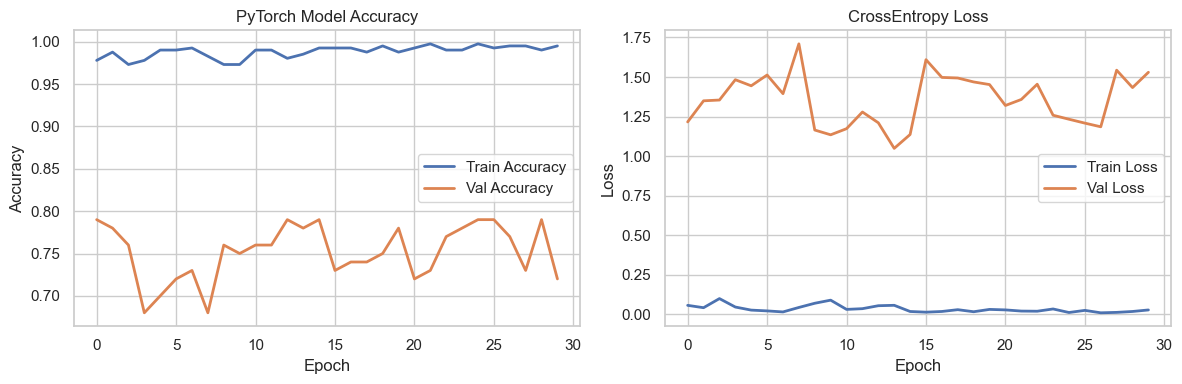

In [38]:
# Hyperparameters
epochs = 30
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Tracking history for plotting
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Starting training...")

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train() # Set model to training mode
    running_loss, running_corrects, total_samples = 0.0, 0, 0

    for images, tabular, labels in best_train_loader:
        # Move data to GPU
        images, tabular, labels = images.to(device), tabular.to(device), labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images, tabular)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels.data).item()
        total_samples += images.size(0)

    epoch_train_loss = running_loss / total_samples
    epoch_train_acc = running_corrects / total_samples

    # --- VALIDATION PHASE ---
    model.eval() # Set model to evaluation mode (disables dropout)
    val_loss, val_corrects, val_samples = 0.0, 0, 0

    with torch.no_grad(): # Disable gradient calculation for speed
        for images, tabular, labels in best_val_loader:
            images, tabular, labels = images.to(device), tabular.to(device), labels.to(device)

            outputs = model(images, tabular)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * images.size(0)
            val_corrects += torch.sum(preds == labels.data).item()
            val_samples += images.size(0)

    epoch_val_loss = val_loss / val_samples
    epoch_val_acc = val_corrects / val_samples

    # Save metrics
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")

# Plotting the Results
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy', lw=2)
plt.plot(history['val_acc'], label='Val Accuracy', lw=2)
plt.title('PyTorch Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', lw=2)
plt.plot(history['val_loss'], label='Val Loss', lw=2)
plt.title('CrossEntropy Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()